In [2]:
 #!/usr/bin/env python
from scipy.stats import expon
from scipy.stats import uniform
from scipy.stats import norm
from scipy.stats import multivariate_normal
from numpy.random import multinomial
from numpy.random import uniform
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from scipy.stats import truncnorm
import math
from scipy.stats import mvn
np.set_printoptions(suppress=True)
import pyreadr
import time
import sys

In [37]:
data = pyreadr.read_r('/home/groups/juliapr/Bingjing/code/boundedcoal/syndata/syn2data_tip1001.rda') #args[1] range from 1 to 300
points_inhomo = np.array(data["coal_time"]).squeeze()

points_inhomo=points_inhomo[0]
print(points_inhomo)

[0.00240455 0.00328411 0.01454572 0.01591656 0.01634529 0.02447151
 0.02887418 0.03169353 0.04330504 0.04502761 0.04895552 0.04901656
 0.05128252 0.05182761 0.05817806 0.05935085 0.06152027 0.06389851
 0.06451028 0.07376368 0.07419093 0.07592113 0.08435126 0.12395106
 0.1273765  0.13071079 0.131077   0.13461952 0.13551656 0.13726362
 0.14662466 0.17697984 0.17740709 0.17953949 0.18165098 0.18905735
 0.19080751 0.194125   0.21014172 0.21050793 0.21390825 0.22449908
 0.22838612 0.23296585 0.23503611 0.23878902 0.24398501 0.24812945
 0.25716011 0.26284952 0.27276481 0.27386851 0.27744598 0.27993894
 0.28219315 0.28445487 0.2845159  0.30503454 0.31096004 0.32771842
 0.3288855  0.34810245 0.35066386 0.35237592 0.35701791 0.35805249
 0.36250868 0.36313594 0.37239533 0.3777403  0.3787077  0.39572204
 0.40132854 0.4033716  0.42760911 0.45015822 0.46466806 0.48897511
 0.49481669 0.49982047 0.5060442  0.51665125 0.52244843 0.53775791
 0.55767515 0.57818053 0.58164403 0.58835596 0.60317672 0.6103

In [52]:


T=1
bin_num=100
x=np.linspace(0,T,bin_num+1)[1:bin_num+1] 
c=1
def inten2(t):
    return 25*np.exp(-5*t)
intensity=inten2(x)

ntip=100


def expo_quad_kernel(theta0,theta1,xn,xm): # 1,0.1
    return theta0*np.exp(-theta1/2*np.sum((xn - xm)**2))

def expo_quad_kernel2(theta0,theta1,xn,t1,t2): # 1,0.1
    return np.sqrt(np.pi/2/theta1)*theta0*(math.erf(np.sqrt(theta1/2)*(t2-xn))-math.erf(np.sqrt(theta1/2)*(t1-xn)))



def expo_quad_kernel3(theta0,theta1,t1,t2,t3,t4): # 1,0.1
    return  np.sqrt(np.pi/2/theta1)*theta0*(    (t2-t3)*math.erf(  np.sqrt(theta1/2) *(t2-t3)    )- (t2-t4)*math.erf(  np.sqrt(theta1/2) *(t2-t4)    )
                                            -(t1-t3)*math.erf(   np.sqrt(theta1/2) *(t1-t3)        )+  (t1-t4)*math.erf(  np.sqrt(theta1/2) *(t1-t4)    ))+theta0/theta1*( np.exp(  -theta1/2*(t2-t3)**2    ) -np.exp(  -theta1/2*(t1-t3)**2    )  - np.exp(  -theta1/2*(t2-t4)**2    ) 
                +np.exp(  -theta1/2*(t1-t4)**2    ))
        

from math import comb
com_vec=np.zeros(ntip-1)

for mmm in range(ntip-1):
   
    com_vec[mmm]=comb(ntip-mmm,2)
    

N=(ntip-1)
Ngrid=100
K= ntip-1  # counts of integrals
x4=np.linspace(0,T,Ngrid+1)[1:Ngrid+1] 
xxx=np.concatenate([x4, points_inhomo])

def chol_sample(mean, cov_chol):
    return mean + cov_chol @ np.random.standard_normal(mean.size)

def log_lik(f,ns):
    #ns is # of Ngrids
    if np.prod(f>0)==0:
        return float('-inf') 
    else:
        return np.sum(np.log(f[:,Ngrid:Ngrid+ns])) -np.sum(com_vec*(f[:,(Ngrid+ns):(Nfinal)]))
    

def elliptical_slice(initial_theta,prior,lnpdf,pdf_params=(),
                     cur_lnpdf=None,angle_range=None):
    """
    NAME:
       elliptical_slice
    PURPOSE:
       Markov chain update for a distribution with a Gaussian "prior" factored out
    INPUT:
       initial_theta - initial vector
       prior - cholesky decomposition of the covariance matrix 
               (like what numpy.linalg.cholesky returns), 
               or a sample from the prior
       lnpdf - function evaluating the log of the pdf to be sampled
       pdf_params= parameters to pass to the pdf
       cur_lnpdf= value of lnpdf at initial_theta (optional)
       angle_range= Default 0: explore whole ellipse with break point at
                    first rejection. Set in (0,2*pi] to explore a bracket of
                    the specified width centred uniformly at random.
    OUTPUT:
       new_theta, new_lnpdf
    HISTORY:
       Originally written in matlab by Iain Murray (http://homepages.inf.ed.ac.uk/imurray2/pub/10ess/elliptical_slice.m)
       2012-02-24 - Written - Bovy (IAS)
    """
    D= len(initial_theta)
    if cur_lnpdf is None:
        cur_lnpdf= lnpdf(initial_theta,*pdf_params)

    # Set up the ellipse and the slice threshold
    if len(prior.shape) == 1: #prior = prior sample
        nu= prior
    else: #prior = cholesky decomp
        if not prior.shape[0] == D or not prior.shape[1] == D:
            raise IOError("Prior must be given by a D-element sample or DxD chol(Sigma)")
        nu= np.dot(prior,np.random.normal(size=D))
    hh = math.log(np.random.uniform()) + cur_lnpdf

    # Set up a bracket of angles and pick a first proposal.
    # "phi = (theta'-theta)" is a change in angle.
    if angle_range is None or angle_range == 0.:
        # Bracket whole ellipse with both edges at first proposed point
        phi= np.random.uniform()*2.*math.pi
        phi_min= phi-2.*math.pi
        phi_max= phi
    else:
        # Randomly center bracket on current point
        phi_min= -angle_range*np.random.uniform()
        phi_max= phi_min + angle_range
        phi= np.random.uniform()*(phi_max-phi_min)+phi_min

    # Slice sampling loop
    while True:
        # Compute xx for proposed angle difference and check if it's on the slice
        xx_prop = initial_theta*math.cos(phi) + nu*math.sin(phi)
        cur_lnpdf = lnpdf(xx_prop,*pdf_params)
        if cur_lnpdf > hh:
            # New point is on slice, ** EXIT LOOP **
            break
        # Shrink slice to rejected point
        if phi > 0:
            phi_max = phi
        elif phi < 0:
            phi_min = phi
        else:
            raise RuntimeError('BUG DETECTED: Shrunk to current position and still not acceptable.')
        # Propose new angle difference
        phi = np.random.uniform()*(phi_max - phi_min) + phi_min
    return (xx_prop,cur_lnpdf)

days=np.concatenate([np.zeros(1),points_inhomo])
days
diff=np.diff(days)


Nfinal=Ngrid+N+K
g_mk=2+np.zeros(Nfinal)
g_mk[ Ngrid+N:Ngrid+N+K ]=2*days[N]*diff/sum(diff)

nsim1=500000
nsim2=500000




cov_K=np.zeros((Nfinal,Nfinal))



theta0=  112.083342
theta1=7.031542 

for i in range(Nfinal):
        for j in range(i,Nfinal):
            if (j<Ngrid+N) and (i<Ngrid+N):
                cov_K[i][j]=expo_quad_kernel(theta0,theta1,xxx[i],xxx[j])
            if (j>(Ngrid+N-1)) and (i<(Ngrid+N)):
                cov_K[i][j]=expo_quad_kernel2(theta0,theta1,xxx[i],   days[  j-Ngrid-N  ], days[  j-Ngrid-N+1           ]    )
            if  (i>(Ngrid+N-1)):
                cov_K[i][j]=expo_quad_kernel3(theta0,theta1,days[i-Ngrid-N],days[i-Ngrid-N+1],  days[j-Ngrid-N],days[j-Ngrid-N+1 ]          )  
            if j!=i:
                cov_K[j][i]=cov_K[i][j]

cov_K_noise=cov_K
noise_var=1e-4
min_eig=np.min(np.real(np.linalg.eigvals(cov_K_noise)))
while(min_eig<1e-10):
    print('1')
    cov_K_noise += np.eye(Nfinal)*noise_var
    min_eig=np.min(np.real(np.linalg.eigvals(cov_K_noise)))
    
cov_K_chol= np.linalg.cholesky(cov_K_noise)
print('end')

1
end


In [53]:

for ite in range(nsim1):
    if (ite%100000==0):
        print(ite)#cov_K is the covariance matrix
    prior=chol_sample(mean=np.zeros(Nfinal), cov_chol=cov_K_chol)#nu
    g_mk,curloglike=elliptical_slice(g_mk.reshape(1,-1),prior,log_lik,pdf_params=[N],cur_lnpdf=None,angle_range=None)

0
0
100000
200000
300000
400000


In [54]:

 g_mk_list=[]
g_mk_list2=[]
g_mk_list3=[]
theta_list=[]
#theta=0.01


for ite in range(nsim2):
    if (ite%100000==0):
        print(ite)#cov_K is the covariance matrix
   
    prior=chol_sample(mean=np.zeros(Nfinal), cov_chol=cov_K_chol)#nu
    g_mk,curloglike=elliptical_slice(g_mk.reshape(1,-1),prior,log_lik,pdf_params=[N],cur_lnpdf=None,angle_range=None)
    g_mk_list2.append(g_mk[0][0:Ngrid])
    g_mk_list3.append(g_mk[0][Ngrid:Nfinal])
    

0
100000
200000
300000
400000


Text(0.5, -0.2, 'latent GP at midpoint')

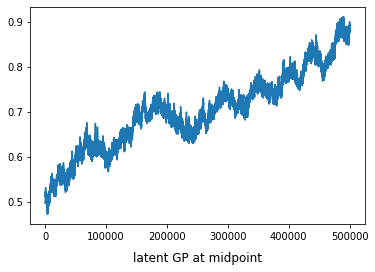

In [55]:
plt.figure()
plt.plot(np.array(g_mk_list2)[:,0])

plt.title('latent GP at midpoint',y=-0.2)

Text(0, 0.5, 'Poisson Intensity $\\lambda(s)$')

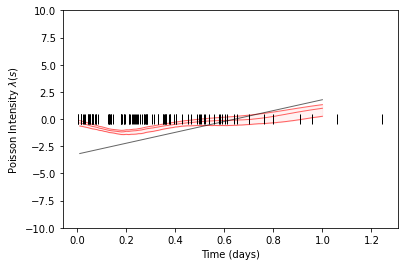

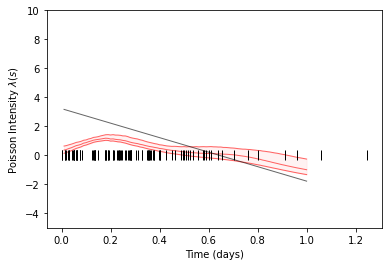

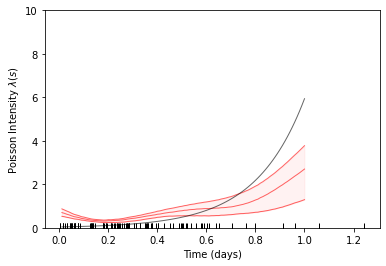

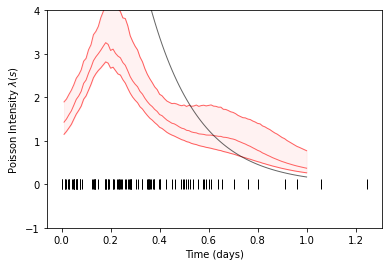

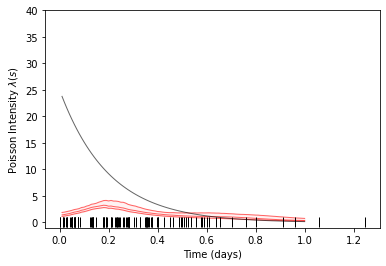

In [57]:
low=np.quantile(np.log(g_mk_list2), 0.025, axis=0)
high=np.quantile(np.log(g_mk_list2), 0.975, axis=0)
me=np.quantile(np.log(g_mk_list2), 0.5, axis=0)



fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)

plt.plot(x,np.log(1/intensity),'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo.flatten(),np.zeros(len(points_inhomo.flatten())),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(-10,10)
plt.xlabel('Time (days)')
plt.ylabel(r'Poisson Intensity $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')
low=np.quantile(np.log(1/np.array(g_mk_list2)), 0.025, axis=0)
high=np.quantile(np.log(1/np.array(g_mk_list2)), 0.975, axis=0)
me=np.quantile(np.log(1/np.array(g_mk_list2)), 0.5, axis=0)



fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)
x=np.linspace(0,T,bin_num+1)[1:bin_num+1] 


plt.plot(x,np.log(intensity),'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo.flatten(),np.zeros(len(points_inhomo.flatten())),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(-5,10)

plt.xlabel('Time (days)')
plt.ylabel(r'Poisson Intensity $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')
low=np.quantile(g_mk_list2, 0.025, axis=0)
high=np.quantile(g_mk_list2, 0.975, axis=0)
me=np.quantile(g_mk_list2, 0.5, axis=0)



fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)

plt.plot(x,1/intensity,'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo.flatten(),np.zeros(len(points_inhomo.flatten())),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(0,10)
plt.xlabel('Time (days)')
plt.ylabel(r'Poisson Intensity $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')
low=np.quantile(1/np.array(g_mk_list2), 0.025, axis=0)
high=np.quantile(1/np.array(g_mk_list2), 0.975, axis=0)
me=np.quantile(1/np.array(g_mk_list2), 0.5, axis=0)



fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)
x=np.linspace(0,T,bin_num+1)[1:bin_num+1] 


plt.plot(x,intensity,'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo.flatten(),np.zeros(len(points_inhomo.flatten())),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(-1,4)

plt.xlabel('Time (days)')
plt.ylabel(r'Poisson Intensity $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')
fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)
x=np.linspace(0,T,bin_num+1)[1:bin_num+1] 

plt.plot(x,intensity,'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo.flatten(),np.zeros(len(points_inhomo.flatten())),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(-1,40)

plt.xlabel('Time (days)')
plt.ylabel(r'Poisson Intensity $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')